# Práctica 04: Analisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudio:** Ingeniería en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo-Agosto 2026

### Unidad 2: Preparación de los Datos

**Nombre del estudiante:** Brandon Diego Islas Lizardi \
**Matrícula:** 230550 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-aling: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.2em; margin: 0;"> 🛒 Prediccion de Amazon Store - Analisis Exploratorio de Datos Completo y Aprendizaje Automatico Predictivo (ML)</h1>
    <p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Prediccion de Precisos - Analisis de Categorias - Ingenieria de Funcionalidades - Compracion de Modelos</p>
</div>

## Tabla de Contenidos

| # | Sección | Descripción |
|---|---|---|
|1.|[Instalaciones y Carga de Datos](#s1). | Librerias, carga del CSV, primeros comandos de estructura | 
|2.|[Diccionario de datos](#s2). | Explicacion del contenido de columnas y calcular el % de datos faltantes |



## 1. Instalaciones y Carga de Datos <a id='s1'></a>

<div style="background: #f0f8ff; padding: 12px; border-left: 4px solid #FF9900; border-radius: 5px00; color: #0066cc;">
    <b>Dataset:</b> Amazon India Listas de Productos - 1,436 productos entre Libros, Kindle, Deportes y más<br>
    <b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoria, longitud del nombre, y disponibilidad<br>
    <b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

print(f' 🦾 Pandas : {pd.__version__}')
print(f' 🦾 Numpy : {np.__version__}')
print(' 🦾 Todas las librerias cargaron con éxito!')

 🦾 Pandas : 2.3.3
 🦾 Numpy : 2.3.5
 🦾 Todas las librerias cargaron con éxito!


In [27]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print (f' shape   : {df_raw.shape}')
print (f' Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

 shape   : (1446, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [19]:
# Column dictionary
col_info = {
    'rl'             : 'URL del Producto en Amazon.in',
    'asin'            : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'            : 'Nombre o Título del Producto',
    'overview'        : 'Breve Reseña del Prodcuto (mayoría vacío [])',
    'price'           : 'Precio como string (e.g. "1,600.00")',
    'currency'        : 'Código de Divisa (todas en INR)',
    'availability'    : 'Texto del Status del Stock (Inventario)',
    'brand'           : 'Nombre de la Marca/Autor ',
    'about_item'      : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'      : 'URLs de Imágenes del Producto',
    'description'     : 'Descripción detalla y completa (mayoría faltante)',
    'specifications'  : 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'      : 'Subcategoría de nivel 1',
    'category_2'      : 'Subcategoría de nivel 2',
    'category_3'      : 'Subcategoría de nivel 3',
    'breadcrumbs'     : 'Ruta de Categorías'
}

print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} |'
        f'{desc[:45]:45s} |'
        f'Missing: {missing_pct:.0f}%'
    )

Diccionario por columnas:
rl                   |URL del Producto en Amazon.in                 |Missing: 0%
asin                 |Número Estandarizado de Identificación por Am |Missing: 0%
name                 |Nombre o Título del Producto                  |Missing: 0%
overview             |Breve Reseña del Prodcuto (mayoría vacío [])  |Missing: 0%
price                |Precio como string (e.g. "1,600.00")          |Missing: 24%
currency             |Código de Divisa (todas en INR)               |Missing: 24%
availability         |Texto del Status del Stock (Inventario)       |Missing: 34%
brand                |Nombre de la Marca/Autor                      |Missing: 1%
about_item           |Detalles/Especificaciones (mayoría faltante)  |Missing: 92%
img_source           |URLs de Imágenes del Producto                 |Missing: 1%
description          |Descripción detalla y completa (mayoría falta |Missing: 92%
specifications       |Especificaciones Técnicas                     |Missing: 

## 3. Limpieza de datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parseas el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [20]:
# =====================================================================
# SECTION 3- Data Cleaning
# =====================================================================
df = df_raw.copy()

# ---------------------------------------------------------------------
# —- Parse price —-
# ---------------------------------------------------------------------
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)


# ---------------------------------------------------------------------
# —- Standardise availability —-
# ---------------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:               return 'In Stock'
    if 'unavailable' in a:           return 'Unavailable'
    if '1 to 3' in a:                 return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:   return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)


# ---------------------------------------------------------------------
# —- Text length features —-
# ---------------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words']  = df['name'].fillna('').str.split().str.len()
df['has_brand']   = df['brand'].notna().astype(int)
df['has_desc']    = df['description'].notna().astype(int)
df['has_specs']   = df['specifications'].notna().astype(int)


# ---------------------------------------------------------------------
# —- Duplicate check —-
# ---------------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

# Mostrar las primeras 5 filas con columnas seleccionadas
df[['name', 'price_clean', 'avail_clean', 'primary_category', 'name_length']].head(5)

✅ Price parsed: 1,096 / 1,450 products
✅ Duplicate ASINs: 9
✅ Availability categories: {'In Stock': 609, 'Unknown': 488, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 116, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


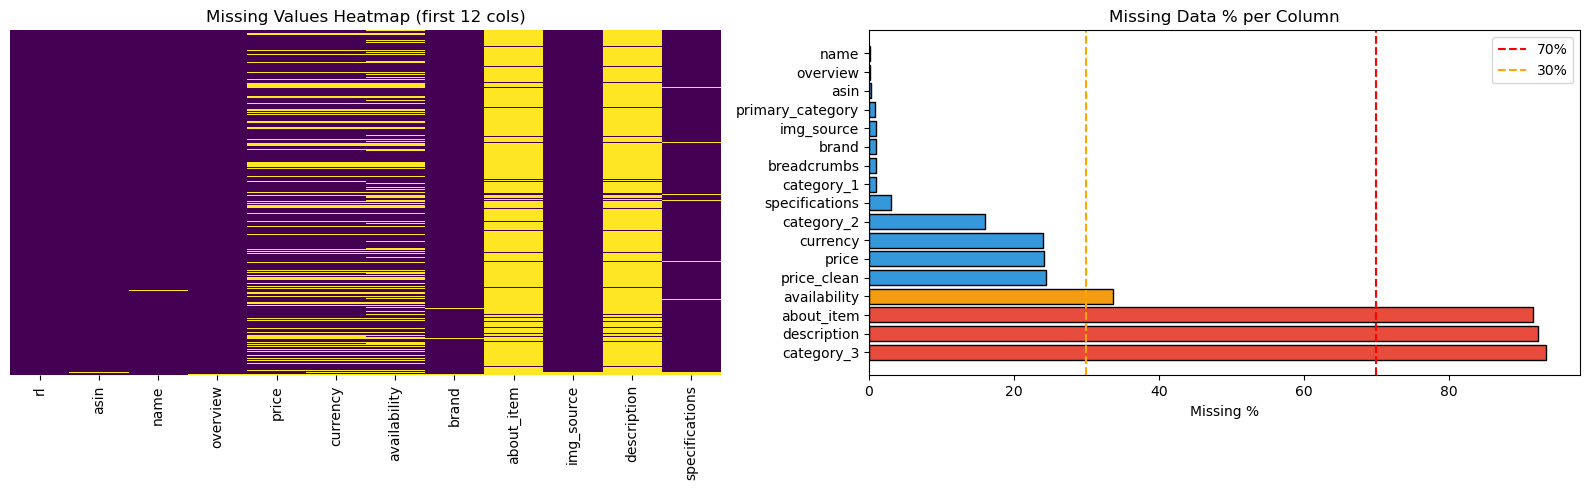

                  Missing Count  Missing Pct
category_3                 1354         93.4
description                1339         92.3
about_item                 1328         91.6
availability                488         33.7
price_clean                 354         24.4
price                       350         24.1
currency                    348         24.0
category_2                  232         16.0
specifications               43          3.0
category_1                   14          1.0
breadcrumbs                  14          1.0
brand                        14          1.0
img_source                   14          1.0
primary_category             11          0.8
asin                          4          0.3
overview                      3          0.2
name                          2          0.1


In [28]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())